In [1]:
# A third try at numerically solving the advection diffusion equation
# Use Dirichlet boundary condition
# Test if the flow speed crosses over more than 1 cell per time step, if so,
#     suppose q*dt reaches the k-th cell, then merge cells 1-k into one
#     fictional cell. The average speed in the fictional cell is
#     0.5*(q_{in,1}, q_{out,k}). Solve using that fictional cell, then
#     map back assuming the real cells that belong to the fictional cell
#     are perfectly mixed.
# This is only likely to happen for the top few ELM layers.

import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import itertools as it
from tqdm import tqdm
from scipy.linalg import expm, inv, pinv

zsoii = np.array([0, 0.0175, 0.0451, 0.0906, 0.1655, 0.2891, 0.4929, 0.8289, 
                1.3828, 2.2961, 3.8019])
zsoi = np.array([0.007100635, 0.027925, 0.06225858, 0.1188651, 0.2121934,
                0.3660658, 0.6197585, 1.038027, 1.727635, 2.864607])
"""
zsoii = np.linspace(0, 1, 11)
zsoi = np.convolve(zsoii, [0.5,0.5], mode = 'valid')
"""
dz = np.diff(zsoii)

# number of soil layers
nlevsoi = 10

In [2]:
def matrix_ode_solution(A, R, C0, t):
    """
    Solves the ODE: dC/dt = A C + R with initial condition C(0)=C0 using the analytical formula.

    Parameters:
    -----------
    A : numpy.ndarray
        Square matrix (n x n) that defines the linear system.
    R : numpy.ndarray
        Constant vector (or column matrix) of dimension n.
    C0 : numpy.ndarray
        Initial condition vector of dimension n.
    t : float or numpy.ndarray
        Time value(s) at which the solution is computed.

    Returns:
    --------
    C : numpy.ndarray
        The solution evaluated at time t. If t is a scalar, the output is a vector (n,).
        If t is an array, the output is of shape (n, len(t)).
    """
    n = A.shape[0]
    C_vals = np.zeros(n)
    
    # Attempt to compute the inverse of A; if singular, use the pseudo-inverse
    try:
        A_inv = inv(A)
    except np.linalg.LinAlgError:
        A_inv = pinv(A)
    
    # Compute the solution for each time point
    expA_t = expm(A * t)  # Compute the matrix exponential e^(A * time)
    # Full solution: e^(A t)*C0 + A^(-1)*(e^(A t) - I)*R
    C_vals = expA_t @ C0 + A_inv @ ((expA_t - np.eye(n)) @ R)
        
    return C_vals

In [3]:
def a_step(c_prev, q_int, theta, watsat, sourcesink, d0, dt, euler):
    """
    c_prev - start concentration (mol/kg)
    q_int - water flux at grid boundaries (m/s)
    theta - soil moisture value (m3/m3)
    watsat - porosity
    sourcesink - source/sink strength (mol/kg/s)
    d0 - diffusion coefficient in water (m2/s)
    dt - time step size (s)
    """

    ## it doesn't matter if I multiply in here or outside
    #q_int = q_int * dt
    #sourcesink = sourcesink * dt
    #d0 = d0 * dt

    # convert Darcy velocity at interfaces to grid centers
    q = q_int[1:]*(zsoi-zsoii[:-1])/dz + q_int[:-1]*(zsoii[1:]-zsoi)/dz
    ## (double check the weights are correct)
    ## plt.plot(zsoii, q_int, '-o')
    ##plt.plot(zsoi, q, '-x')

    # the distance between nodes (center of grids)
    dx = np.diff(zsoi)

    # pad half grids at bottom to facilitate calculating cell mixing
    dx = np.append(dx, dz[-1])

    # cells that are crossed over by its average speed
    # will be completely mixed; identify those cells
    fic_pts = []
    fic_sum = 0
    q_curr = -1
    for k in range(len(dx)):
        # previous grid's q crosses the distance between the previous
        # grid and the current grid; append the current grid to
        # previous grid, 
        if q_curr*dt >= fic_sum:
            q_curr = (q_curr*fic_sum + q[k]*dx[k]) / (dx[k]+fic_sum)
            fic_sum = fic_sum + dx[k]
        else:
            # this cell is not crossed over, make it the start
            # of the next round of accumulation
            fic_pts.append(k)
            q_curr = q[k]
            fic_sum = dx[k]

    #print(q*dt)
    #print(dx)
    #print(fic_pts)

    # append an ending cell
    fic_pts = np.append(fic_pts, len(dx))

    # create the contents of the fictional cells
    fic_dx = []
    fic_cprev = []
    fic_q = []
    fic_theta = []
    fic_watsat = []
    fic_srcsnk = []

    for p in range(len(fic_pts)-1):
        k1 = fic_pts[p]
        k2 = fic_pts[p+1]
        tot_len = sum(dx[k1:k2])

        fic_dx.append( tot_len )
        fic_cprev.append( sum(c_prev[k1:k2] * dx[k1:k2]) / tot_len )
        fic_q.append( 0.5*(q_int[k1] + q_int[k2]) )
        fic_theta.append( sum(theta[k1:k2] * dx[k1:k2]) / tot_len )
        fic_watsat.append( sum(watsat[k1:k2] * dx[k1:k2]) / tot_len )
        fic_srcsnk.append( sum(sourcesink[k1:k2] * dx[k1:k2]) / tot_len )
    
    #print(fic_dx)

    # do everything on the fictional cells

    # pad half grids at top
    fic_dx = np.insert(np.insert(fic_dx, 0, fic_dx[0]), 0, 0)

    # pad half grids to keep indexing consistent with dx
    fic_q = np.append(np.insert(fic_q, 0, 0), 0)
    fic_cprev = np.append(np.insert(fic_cprev, 0, 0), 0)
    fic_theta = np.append(np.insert(fic_theta, 0, 0.6), 0.6)
    fic_watsat = np.append(np.insert(fic_watsat, 0, 0.6), 0.6)
    fic_srcsnk = np.append(np.insert(fic_srcsnk, 0, 0), 0)

    #print(fic_dx)
    #print(fic_q)
    #print(fic_cprev)
    #print(fic_theta)
    #print(fic_watsat)
    #print(fic_srcsnk)

    # calculate the layerwise effective diffusion coefficient
    fic_Deff = d0 * fic_theta**(10/3) / fic_watsat**2

    # assemble the matrix: dx/dt = Ax, for use in ODE integration
    fic_A = np.zeros([len(fic_q), len(fic_q)])
    for i in range(1, len(fic_q)-1):
        # Deff * d^2 C / dx^2
        fic_A[i,i-1] = fic_Deff[i] * 2 / (fic_dx[i]*(fic_dx[i] + fic_dx[i+1]))
        fic_A[i,i] = - fic_Deff[i] * 2 / (fic_dx[i]*fic_dx[i+1])
        fic_A[i,i+1] = fic_Deff[i] * 2 / (fic_dx[i+1]*(fic_dx[i] + fic_dx[i+1]))

        # calculate d Deff / dx
        dDeff = - fic_dx[i+1] / (fic_dx[i]*(fic_dx[i] + fic_dx[i+1])) * fic_Deff[i-1] + \
                (fic_dx[i+1]-fic_dx[i]) / (fic_dx[i]*fic_dx[i+1]) * fic_Deff[i] + \
                fic_dx[i] / (fic_dx[i+1]*(fic_dx[i] + fic_dx[i+1])) * fic_Deff[i+1]

        # Add (d Deff / dx - q) * dC / dx
        fic_A[i,i-1] = fic_A[i,i-1] + (dDeff - fic_q[i]) * (-fic_dx[i+1] / (fic_dx[i]*(fic_dx[i] + fic_dx[i+1])))
        fic_A[i,i] = fic_A[i,i] + (dDeff - fic_q[i]) * (fic_dx[i+1] - fic_dx[i]) / (fic_dx[i]*fic_dx[i+1])
        fic_A[i,i+1] = fic_A[i,i+1] + (dDeff - fic_q[i]) * fic_dx[i] / (fic_dx[i+1]*(fic_dx[i]+fic_dx[i+1]))

    if euler == 'forward':
        # use forward Euler integration

        # calculate \theta * dx/dt
        fic_dcdt = np.matmul(fic_A, fic_cprev) / fic_theta + fic_srcsnk / fic_theta

        fic_cnext = fic_dcdt * dt + fic_cprev

    elif euler == 'backward':
        # use backward Euler integration

        # \theta * (C_{i+1} - C_{i}) / dt = A C_{i+1} + R
        # which simplifies to
        # (diag(\theta)-A*dt) * C_{i+1} = \theta*C_i + R*dt
        fic_Arev = np.diag(fic_theta) - fic_A*dt
        fic_B = fic_theta*fic_cprev + fic_srcsnk * dt
        fic_cnext = np.linalg.solve(fic_Arev, fic_B)
    
    elif euler == 'Cr-Ni':
        # use Crank-Nicholson integration

        # \theta * (C_{i+1} - C_{i}) / dt = 0.5 * A (C_{i} + C_{i+1}) + R
        # which simplifies to
        # (diag(\theta)-0.5*A*dt) * C_{i+1} = 0.5*A*C_i + \theta*C_i + R*dt
        fic_Arev = np.diag(fic_theta) - 0.5*fic_A*dt
        fic_B = fic_theta*fic_cprev + 0.5*np.matmul(fic_A,fic_cprev)*dt + fic_srcsnk * dt
        fic_cnext = np.linalg.solve(fic_Arev, fic_B)

    elif euler == 'explicit':
        #print(np.max(np.matmul(fic_A, 1/np.diag(fic_theta))),
        #      np.min(np.matmul(fic_A, 1/np.diag(fic_theta))))
        #print(np.max(fic_A.reshape(-1)), np.min(fic_A.reshape(-1)))

        fic_Arev = np.matmul(fic_A, np.diag(1/fic_theta))
        fic_B = fic_srcsnk/fic_theta

        fic_cnext = matrix_ode_solution(fic_Arev, fic_B, fic_cprev, dt)

    #print(fic_cnext)

    c_next = np.full(nlevsoi, np.nan)

    for p in range(len(fic_pts)-1):
        k1 = fic_pts[p]
        k2 = fic_pts[p+1]
        c_next[k1:k2] = fic_cnext[p+1]


    # force positive and re-scale to insure mass balance
    tot = sum(c_next * dz)
    c_next = np.maximum(c_next, 0)
    if sum(c_next * dz) > 0:
        c_next = c_next * tot / sum(c_next * dz)

    return c_next # , fic_A

In [4]:
# initial concentration (mol kg-1 water)
c0 = np.zeros(nlevsoi)

# porosity
watsat = np.ones(nlevsoi)*0.6 # hr['watsat'][:, :nlevsoi, 0].values 

# water diffusion coefficient: m2/s
d0 = 7.93e-10 # Ca2+

# constant source strength: mol L-1 (soil volume) s-1
sourcesink = np.zeros(nlevsoi)
sourcesink[0] = 1e-5

9it [00:36,  4.02s/it]


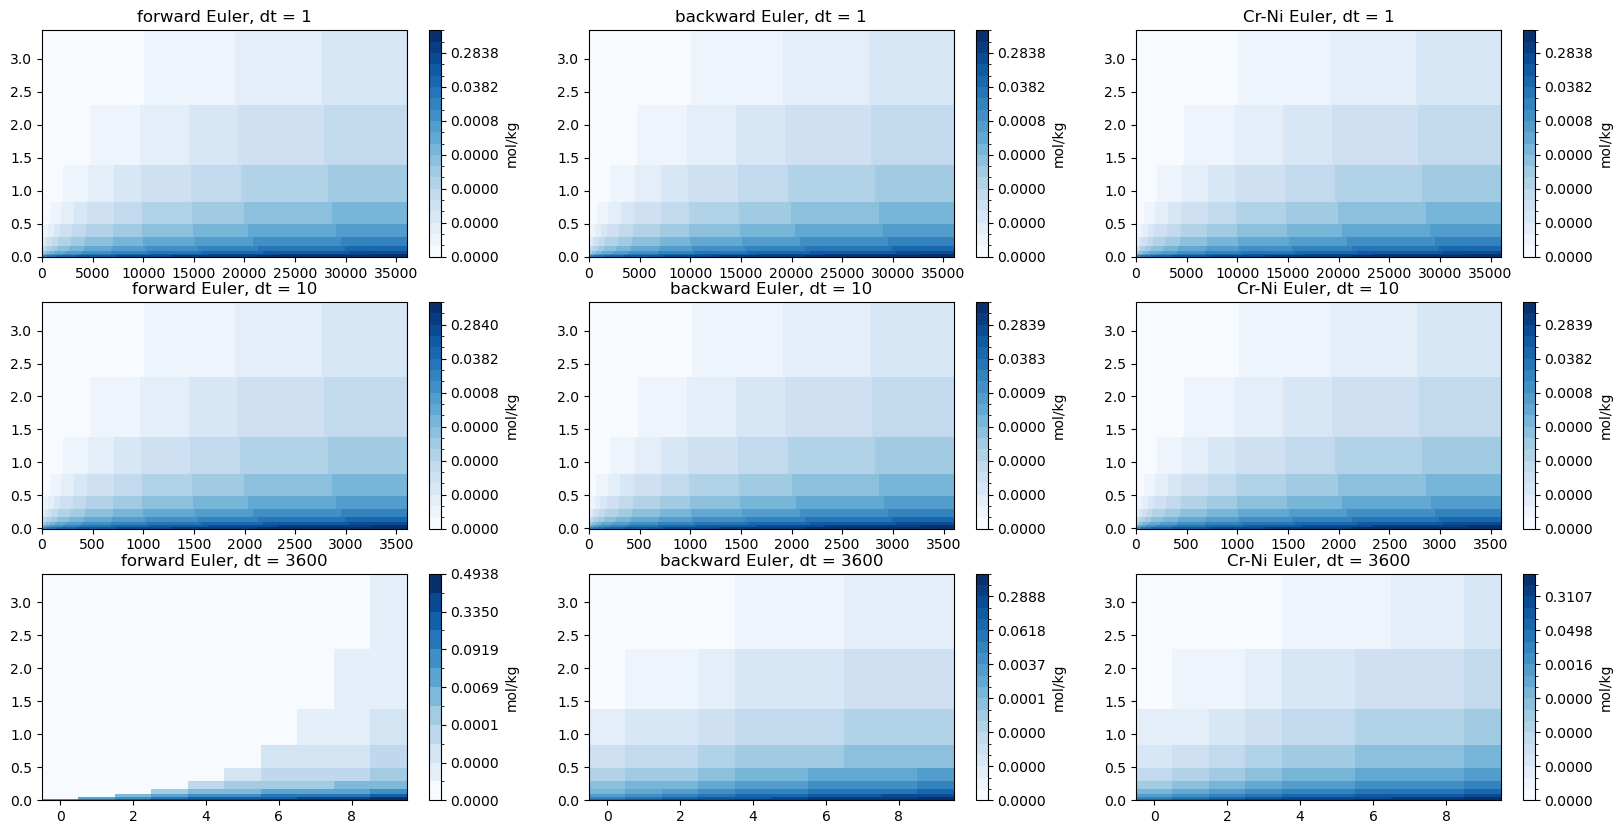

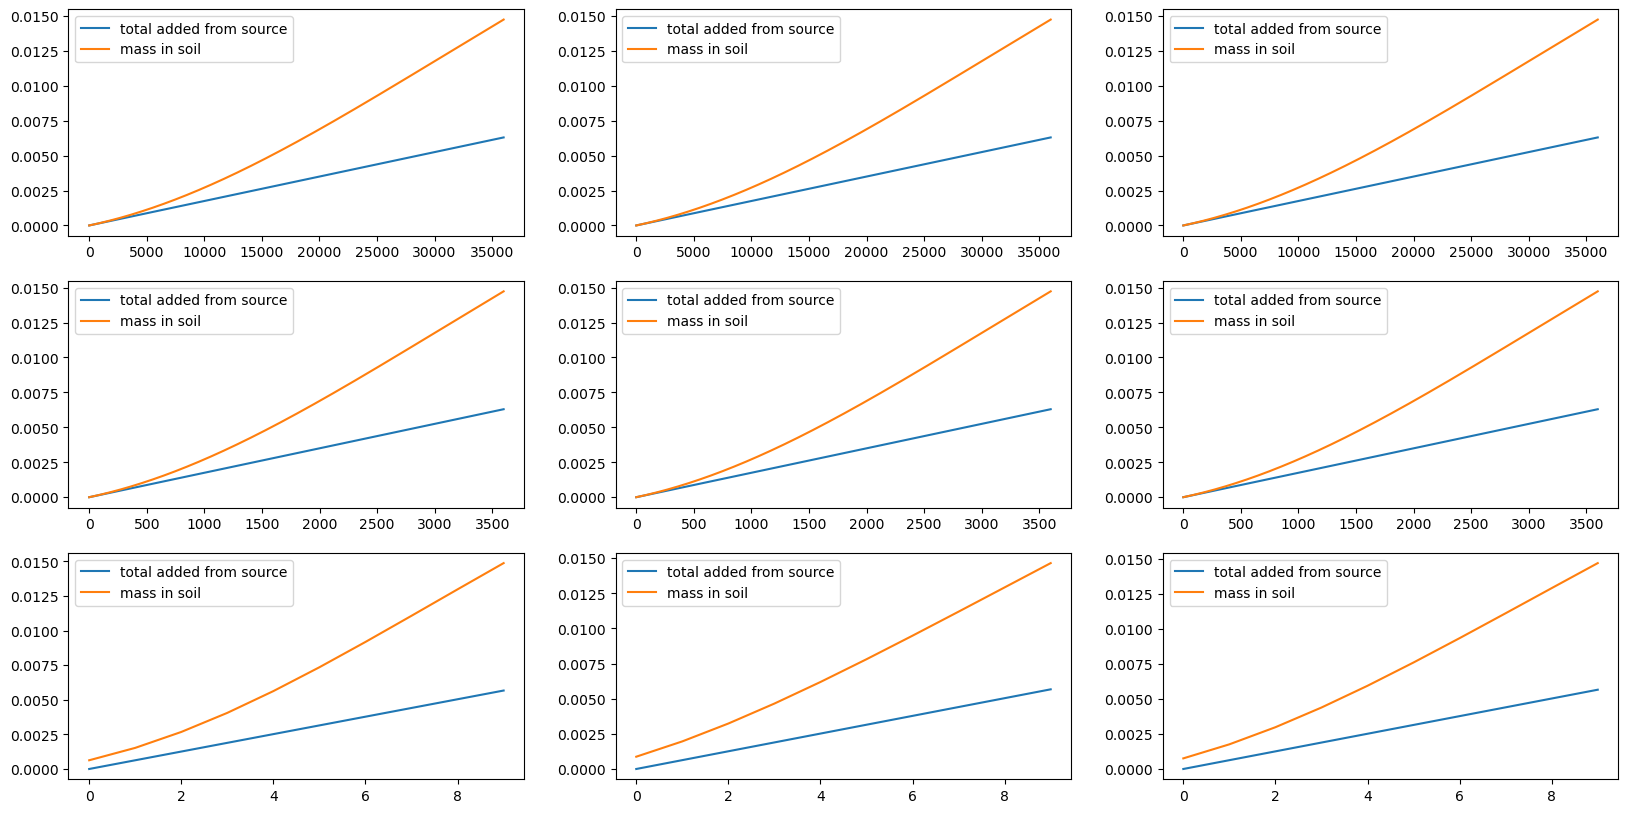

In [5]:
# constant flow rate (m/s)
# at 1e-10 the algorithm works well, at 1e-6 it overshoots, at 1e-4 it is terrible
q_int = np.ones(nlevsoi+1) * 1e-6

# constant soil moisture
h2osoi = np.ones(nlevsoi) * 0.4

# size of time step
length = 3600*10 # 3600*50
result_all = {}
for dt, euler in tqdm(it.product([1, 10, 3600], ['forward','backward','Cr-Ni'])): # ,'explicit'
    c_prev = c0
    result = np.full([length//dt, nlevsoi], np.nan)
    for t in range(length//dt):
        result[t, :] = a_step(c_prev, q_int, h2osoi, watsat, sourcesink, d0, dt,
                              euler) # q_int[t,:], h2osoi[t,:]
        c_prev = result[t, :]

        #if t > 25000:
        #    continue

    result_all[(dt,euler)] = result


fig, axes = plt.subplots(3, 3, figsize = (20, 10))
for i,(dt,euler) in enumerate(it.product([1, 10, 3600], ['forward','backward','Cr-Ni'])): # , 'explicit'
    ax = axes.flat[i]
    result = result_all[(dt,euler)]
    levels = np.unique(np.percentile(result.reshape(-1), np.arange(0,101,5)))
    cf = ax.pcolormesh(np.arange(length//dt), zsoi, result.T, 
                       norm = BoundaryNorm(levels, ncolors = 256), cmap = 'Blues')
    plt.colorbar(cf, ax = ax, label = 'mol/kg')
    ax.set_title(f'{euler} Euler, dt = {dt}')
plt.savefig('test_main2.png')


# Add the diagnostis of how much source is added v.s. how much remains in the soil column
# mol/kg * m3/m3 * dz, cumsum
fig, axes = plt.subplots(3, 3, figsize = (20, 10))
for i,(dt,euler) in enumerate(it.product([1, 10, 3600], ['forward','backward','Cr-Ni'])): # ,'explicit'
    ax = axes.flat[i]

    result = result_all[(dt,euler)]
    tot_in = np.sum(result * h2osoi * dz, axis = 1)

    total_added = np.arange(0, 3600*10//dt) * np.sum(sourcesink * dz * dt)

    ax.plot(total_added)
    ax.plot(tot_in)
    ax.legend(['total added from source', 'mass in soil'])

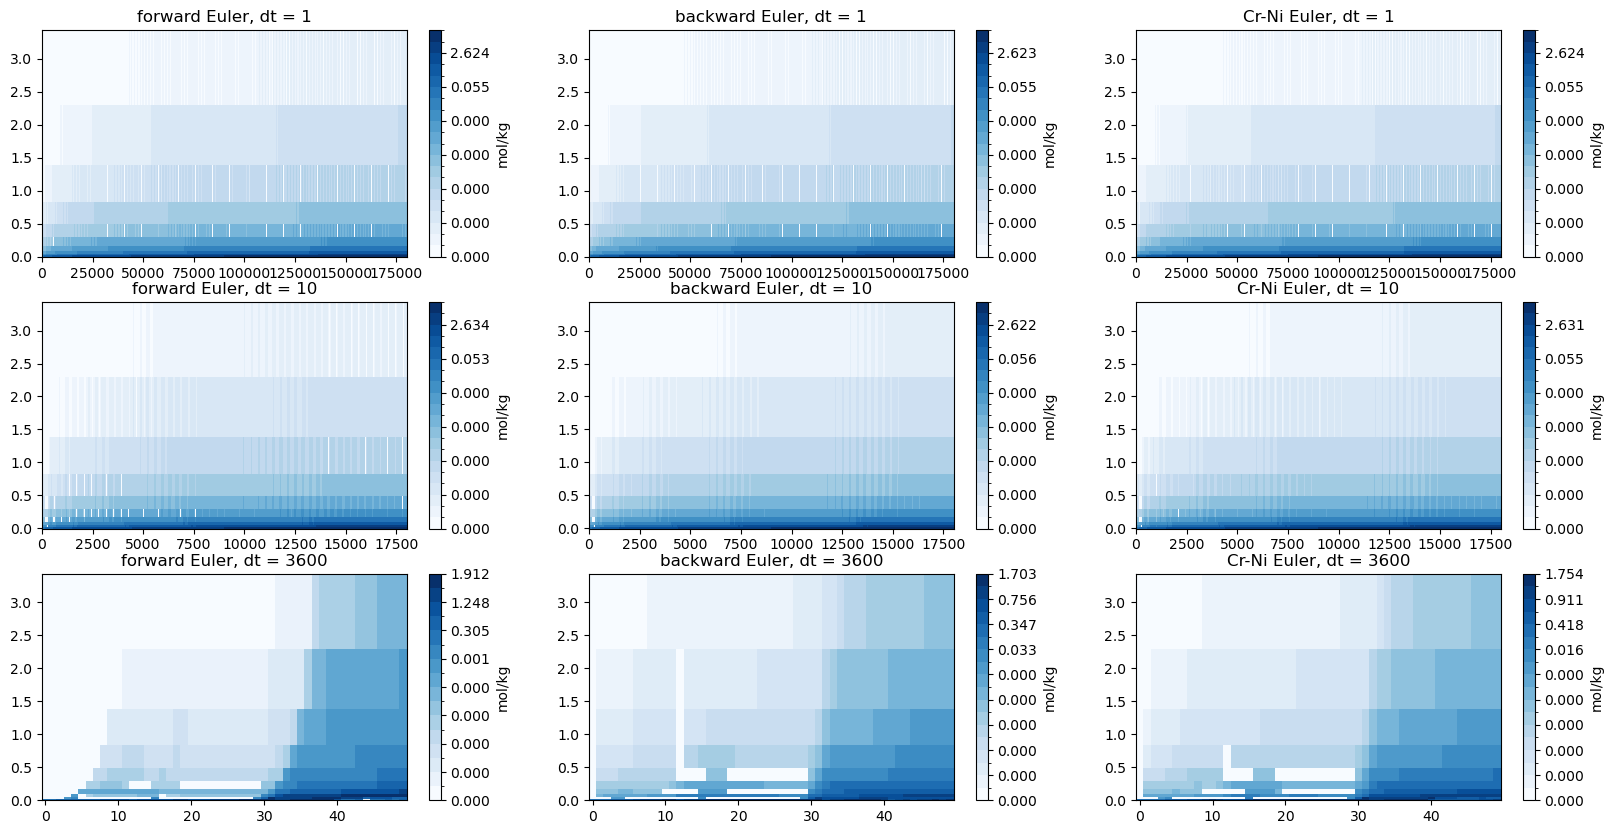

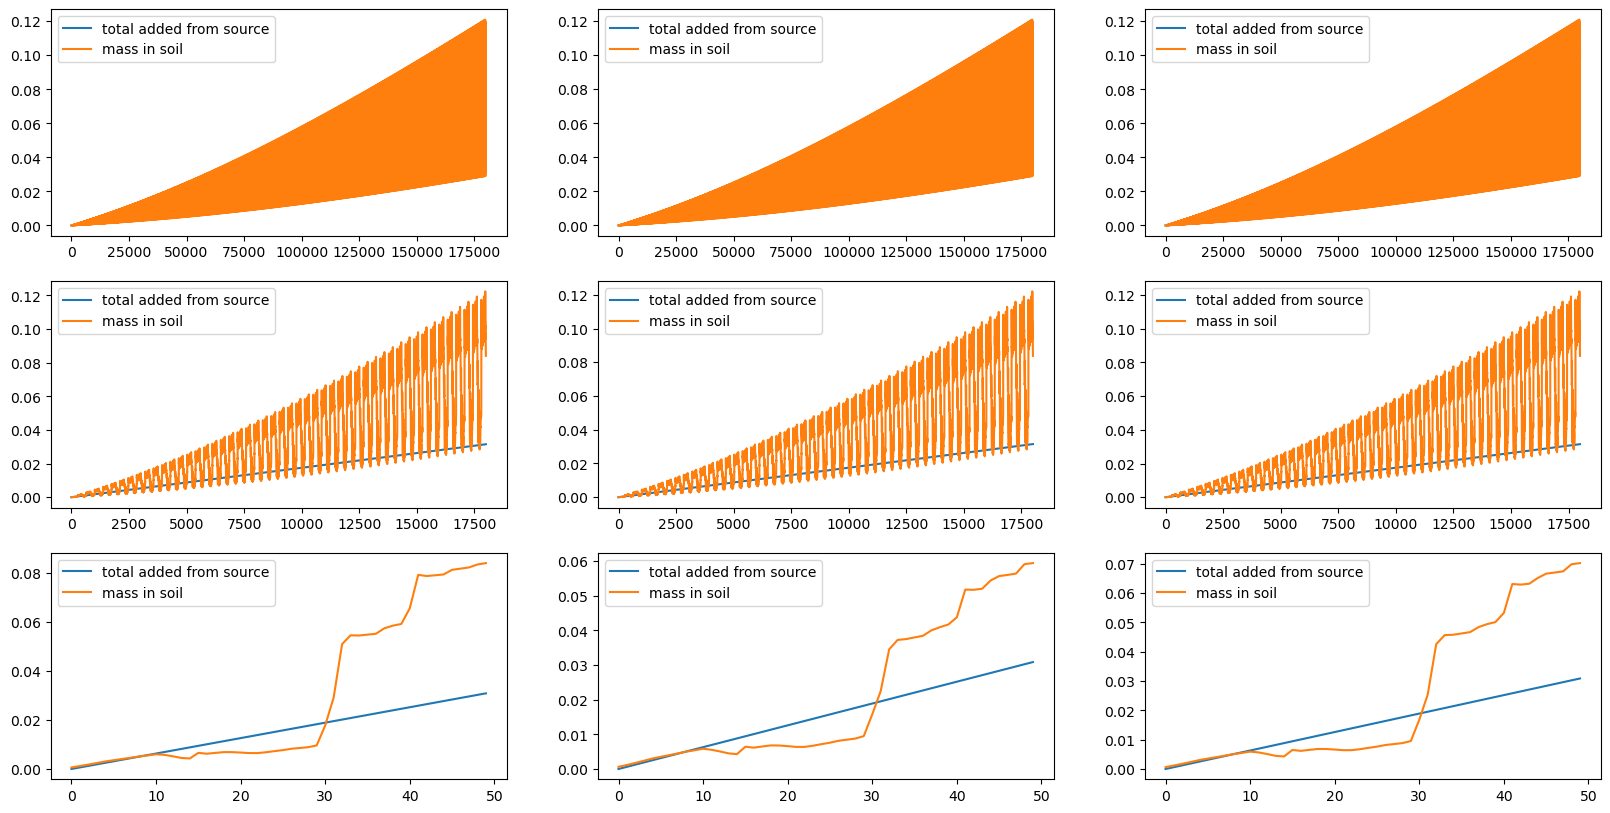

In [6]:
# realistic flow rate and soil moisture
hr = xr.open_dataset(os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                  '20250323_UC_Davis_ICB20TRCNPRDCTCBC_3year_rmethod1erw', 'run', 
                                  '20250323_UC_Davis_ICB20TRCNPRDCTCBC_3year_rmethod1erw.elm.h1.1947-01-01-00000.nc'))
q_int = hr['QIN'][:, :(nlevsoi+1), 0].values * 1e-3 * 24 # mm/s => m/s, account for daily averaging
h2osoi = hr['H2OSOI'][:, :nlevsoi, 0].values # m3/m3 soil moisture
hr.close()

# size of time step
length = 3600*50
result_all = {}
h2o_all = {}
for i,(dt,euler) in enumerate(it.product([1, 10, 3600], ['forward','backward','Cr-Ni'])): # , 'explicit'
    c_prev = c0
    result = np.full([length//dt, nlevsoi], np.nan)
    h2osoi_record = np.full([length//dt, nlevsoi], np.nan)

    for t in range(length//dt):
        result[t, :] = a_step(c_prev, 
                                q_int[np.mod(t, len(q_int)),:], # repeat the same cycle
                                h2osoi[np.mod(t, len(q_int)),:], # repeat the same cycle
                                watsat, sourcesink, d0, dt,
                                euler)
        c_prev = result[t, :]
        h2osoi_record[t, :] = h2osoi[np.mod(t, len(q_int)),:]

    result_all[(dt,euler)] = result
    h2o_all[(dt,euler)] = h2osoi_record

fig, axes = plt.subplots(3, 3, figsize = (20, 10))
for i,(dt,euler) in enumerate(it.product([1, 10, 3600], ['forward','backward','Cr-Ni'])): # , 'explicit'
    ax = axes.flat[i]
    result = result_all[(dt,euler)]
    levels = np.unique(np.percentile(result.reshape(-1), np.arange(0,101,5)))
    cf = ax.pcolormesh(np.arange(length//dt), zsoi, result.T,
                        norm = BoundaryNorm(levels, ncolors = 256), cmap = 'Blues')
    plt.colorbar(cf, ax = ax, label = 'mol/kg')
    ax.set_title(f'{euler} Euler, dt = {dt}')
plt.savefig('test_main2_2.png')

# Add the diagnostis of how much source is added v.s. how much remains in the soil column
# mol/kg * m3/m3 * dz, cumsum
fig, axes = plt.subplots(3, 3, figsize = (20, 10))
for i,(dt,euler) in enumerate(it.product([1, 10, 3600], ['forward','backward','Cr-Ni'])): # , 'explicit'
    ax = axes.flat[i]

    result = result_all[(dt,euler)]
    tot_in = np.sum(result * h2o_all[(dt,euler)] * dz, axis = 1)

    total_added = np.arange(0, len(tot_in)) * np.sum(sourcesink * dz * dt)

    ax.plot(total_added)
    ax.plot(tot_in)
    ax.legend(['total added from source', 'mass in soil'])

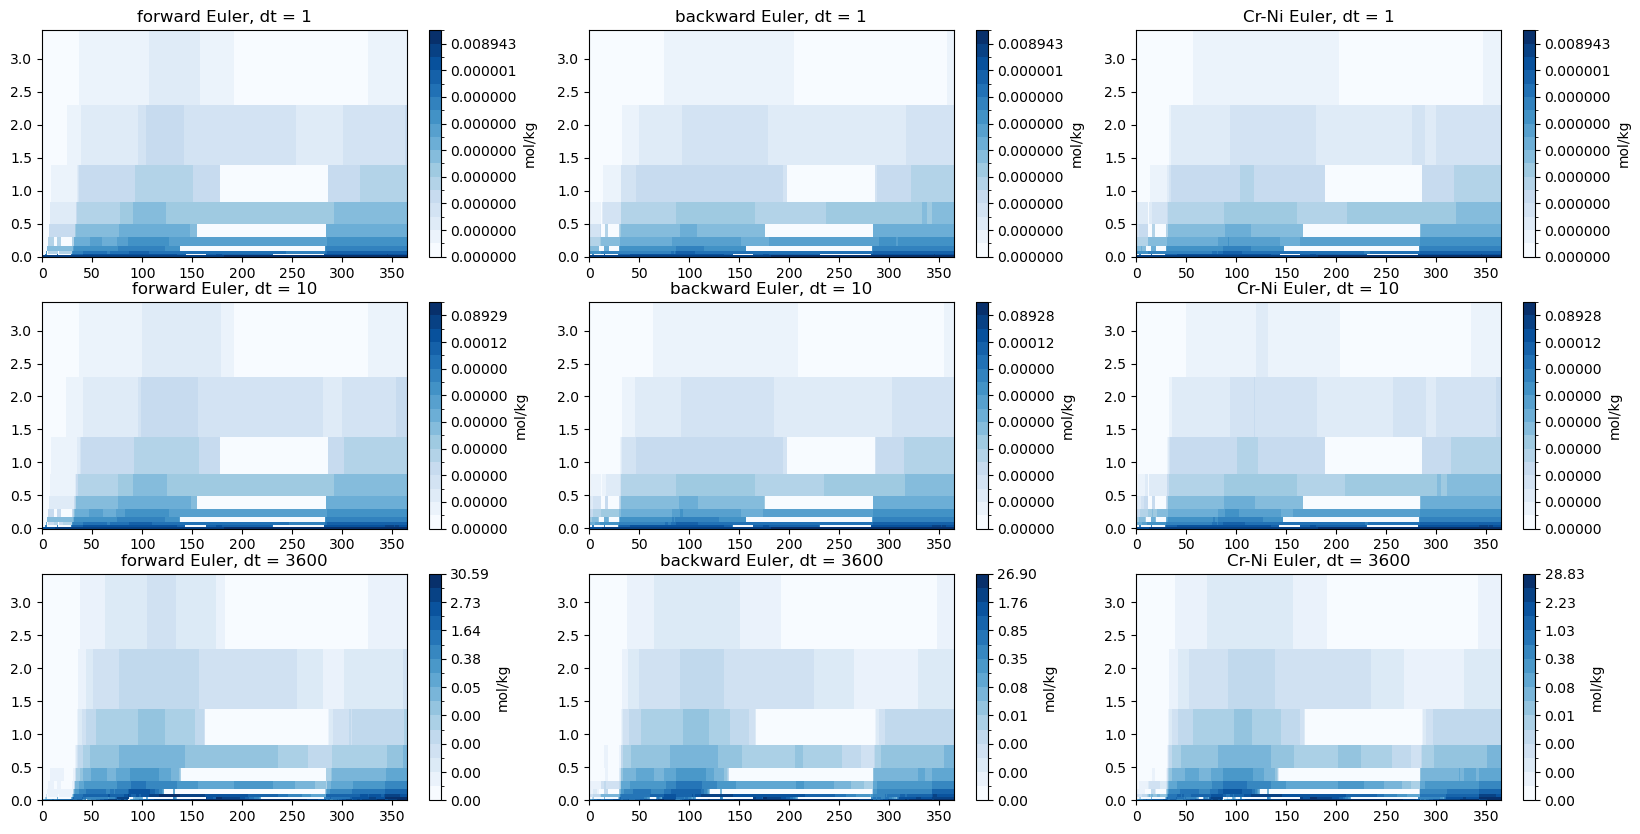

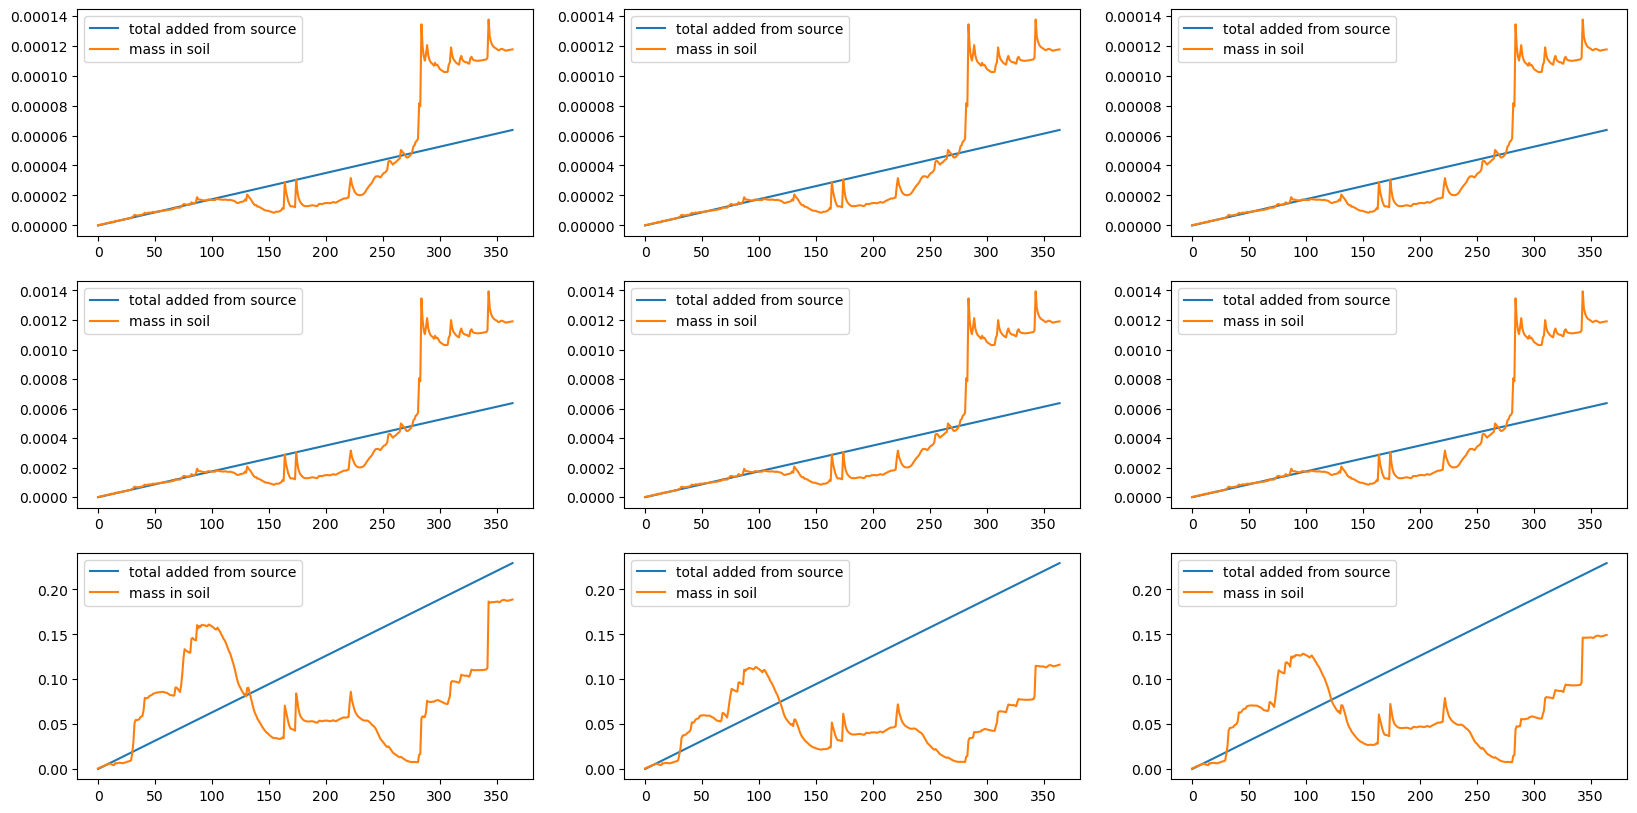

In [7]:
# non-cyclic, same forcing
hr = xr.open_dataset(os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                  '20250323_UC_Davis_ICB20TRCNPRDCTCBC_3year_rmethod1erw', 'run', 
                                  '20250323_UC_Davis_ICB20TRCNPRDCTCBC_3year_rmethod1erw.elm.h1.1947-01-01-00000.nc'))
q_int = hr['QIN'][:, :(nlevsoi+1), 0].values * 1e-3 * 24 # mm/s => m/s, account for daily averaging
h2osoi = hr['H2OSOI'][:, :nlevsoi, 0].values # m3/m3 soil moisture
hr.close()


result_all = {}
for i,(dt,euler) in enumerate(it.product([1, 10, 3600], ['forward','backward','Cr-Ni'])): # , 'explicit'
    c_prev = c0
    result = np.full([365, nlevsoi], np.nan)
    for t in range(365):
        result[t, :] = a_step(c_prev, q_int[t,:], h2osoi[t,:], watsat, sourcesink, d0, dt,
                                euler)
        c_prev = result[t, :]

    result_all[(dt,euler)] = result

fig, axes = plt.subplots(3, 3, figsize = (20, 10))
for i,(dt,euler) in enumerate(it.product([1, 10, 3600], ['forward','backward','Cr-Ni'])): # , 'explicit'
    ax = axes.flat[i]
    result = result_all[(dt,euler)]
    levels = np.unique(np.percentile(result.reshape(-1), np.arange(0,101,5)))
    cf = ax.pcolormesh(np.arange(365), zsoi, result.T,
                        norm = BoundaryNorm(levels, ncolors = 256), cmap = 'Blues')
    plt.colorbar(cf, ax = ax, label = 'mol/kg')
    ax.set_title(f'{euler} Euler, dt = {dt}')
plt.savefig('test_main3.png')

# Add the diagnostis of how much source is added v.s. how much remains in the soil column
# mol/kg * m3/m3 * dz, cumsum
fig, axes = plt.subplots(3, 3, figsize = (20, 10))
for i,(dt,euler) in enumerate(it.product([1, 10, 3600], ['forward','backward','Cr-Ni'])): # , 'explicit'
    ax = axes.flat[i]

    result = result_all[(dt,euler)]
    tot_in = np.sum(result * h2osoi * dz, axis = 1)

    total_added = np.arange(0, 365) * np.sum(sourcesink * dz * dt)

    ax.plot(total_added)
    ax.plot(tot_in)
    ax.legend(['total added from source', 'mass in soil'])